### **Import Libraries**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd

##Data Preprocessing & Dataset

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 345kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.2MB/s]


##Split Data + DataLoaders

In [3]:

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


##CNN Model + Adam Optimizer

In [4]:
simple_cnn = nn.Sequential(

    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(64),
    nn.MaxPool2d(2),

    nn.Flatten(),

    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(128, 10)

).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    simple_cnn.parameters(),
    lr=0.001
)

## Adam (Training)

In [5]:
epochs = 10

adam_train_losses = []
adam_train_accuracies = []

adam_val_losses = []
adam_val_accuracies = []

for epoch in range(epochs):

    simple_cnn.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = simple_cnn(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predicted = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_acc = 100 * correct / total

    adam_train_losses.append(train_loss)

    adam_train_accuracies.append(train_acc)

    simple_cnn.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = simple_cnn(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            predicted = outputs.argmax(dim=1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)

    val_acc = 100 * val_correct / val_total

    adam_val_losses.append(val_loss)

    adam_val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )



Epoch 1 | Train Loss: 0.1662 | Train Acc: 94.90% | Val Loss: 0.0627 | Val Acc: 98.08%
Epoch 2 | Train Loss: 0.0733 | Train Acc: 97.80% | Val Loss: 0.0463 | Val Acc: 98.62%
Epoch 3 | Train Loss: 0.0572 | Train Acc: 98.28% | Val Loss: 0.0479 | Val Acc: 98.74%
Epoch 4 | Train Loss: 0.0473 | Train Acc: 98.58% | Val Loss: 0.0466 | Val Acc: 98.67%
Epoch 5 | Train Loss: 0.0401 | Train Acc: 98.79% | Val Loss: 0.0494 | Val Acc: 98.76%
Epoch 6 | Train Loss: 0.0352 | Train Acc: 98.90% | Val Loss: 0.0421 | Val Acc: 98.83%
Epoch 7 | Train Loss: 0.0350 | Train Acc: 98.97% | Val Loss: 0.0444 | Val Acc: 99.01%
Epoch 8 | Train Loss: 0.0286 | Train Acc: 99.10% | Val Loss: 0.0541 | Val Acc: 98.89%
Epoch 9 | Train Loss: 0.0293 | Train Acc: 99.14% | Val Loss: 0.0511 | Val Acc: 98.96%
Epoch 10 | Train Loss: 0.0284 | Train Acc: 99.14% | Val Loss: 0.0486 | Val Acc: 99.01%


##Adam (Testing)

In [6]:


simple_cnn.eval()

adam_test_loss = 0
adam_correct = 0
adam_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = simple_cnn(images)

        loss = criterion(outputs, labels)

        adam_test_loss += loss.item()

        predicted = outputs.argmax(dim=1)

        adam_total += labels.size(0)

        adam_correct += (predicted == labels).sum().item()

adam_test_loss = adam_test_loss / len(test_loader)

adam_test_accuracy = 100 * adam_correct / adam_total

print("Adam Test Loss:", adam_test_loss)

print("Adam Test Accuracy:", adam_test_accuracy, "%")

Adam Test Loss: 0.03599698017474106
Adam Test Accuracy: 99.12 %


##Adam Visualization

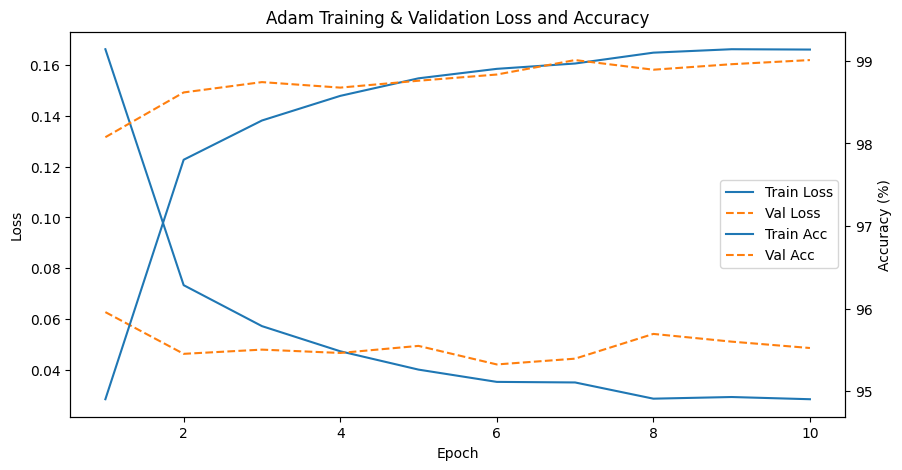

In [7]:
epochs_range = range(1, len(adam_train_losses) + 1)

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.set_xlabel('Epoch')

ax1.set_ylabel('Loss')

ax1.plot(
    epochs_range,
    adam_train_losses,
    label='Train Loss'
)

ax1.plot(
    epochs_range,
    adam_val_losses,
    linestyle='dashed',
    label='Val Loss'
)

ax2 = ax1.twinx()

ax2.set_ylabel('Accuracy (%)')

ax2.plot(
    epochs_range,
    adam_train_accuracies,
    label='Train Acc'
)

ax2.plot(
    epochs_range,
    adam_val_accuracies,
    linestyle='dashed',
    label='Val Acc'
)

plt.title(
    "Adam Training & Validation Loss and Accuracy"
)

lines_1, labels_1 = ax1.get_legend_handles_labels()

lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='center right'
)

plt.show()

##CNN Model + SGD Optimizer

In [8]:
simple_cnn_sgd = nn.Sequential(

    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(64),
    nn.MaxPool2d(2),

    nn.Flatten(),

    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(128, 10)

).to(device)

optimizer_sgd = optim.SGD(
    simple_cnn_sgd.parameters(),
    lr=0.01
)



##SGD (Training)

In [9]:
epochs = 10

sgd_train_losses = []
sgd_train_accuracies = []

sgd_val_losses = []
sgd_val_accuracies = []

for epoch in range(epochs):

    simple_cnn_sgd.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_sgd.zero_grad()

        outputs = simple_cnn_sgd(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_sgd.step()

        running_loss += loss.item()

        predicted = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_acc = 100 * correct / total

    sgd_train_losses.append(train_loss)

    sgd_train_accuracies.append(train_acc)

    simple_cnn_sgd.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = simple_cnn_sgd(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            predicted = outputs.argmax(dim=1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)

    val_acc = 100 * val_correct / val_total

    sgd_val_losses.append(val_loss)

    sgd_val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch 1 | Train Loss: 0.2594 | Train Acc: 92.66% | Val Loss: 0.0747 | Val Acc: 97.77%
Epoch 2 | Train Loss: 0.0902 | Train Acc: 97.37% | Val Loss: 0.0538 | Val Acc: 98.36%
Epoch 3 | Train Loss: 0.0670 | Train Acc: 98.08% | Val Loss: 0.0447 | Val Acc: 98.67%
Epoch 4 | Train Loss: 0.0544 | Train Acc: 98.48% | Val Loss: 0.0416 | Val Acc: 98.67%
Epoch 5 | Train Loss: 0.0459 | Train Acc: 98.67% | Val Loss: 0.0372 | Val Acc: 98.82%
Epoch 6 | Train Loss: 0.0389 | Train Acc: 98.86% | Val Loss: 0.0367 | Val Acc: 98.83%
Epoch 7 | Train Loss: 0.0345 | Train Acc: 99.00% | Val Loss: 0.0341 | Val Acc: 98.89%
Epoch 8 | Train Loss: 0.0290 | Train Acc: 99.18% | Val Loss: 0.0333 | Val Acc: 98.93%
Epoch 9 | Train Loss: 0.0263 | Train Acc: 99.25% | Val Loss: 0.0337 | Val Acc: 99.00%
Epoch 10 | Train Loss: 0.0220 | Train Acc: 99.40% | Val Loss: 0.0329 | Val Acc: 98.91%


##SGD (Testing)

In [10]:

simple_cnn_sgd.eval()

sgd_test_loss = 0
sgd_correct = 0
sgd_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = simple_cnn_sgd(images)

        loss = criterion(outputs, labels)

        sgd_test_loss += loss.item()

        predicted = outputs.argmax(dim=1)

        sgd_total += labels.size(0)

        sgd_correct += (predicted == labels).sum().item()

sgd_test_loss = sgd_test_loss / len(test_loader)

sgd_test_accuracy = 100 * sgd_correct / sgd_total

print("SGD Test Loss:", sgd_test_loss)

print("SGD Test Accuracy:", sgd_test_accuracy, "%")

SGD Test Loss: 0.025365173071405032
SGD Test Accuracy: 99.13 %


##SGD Visualization

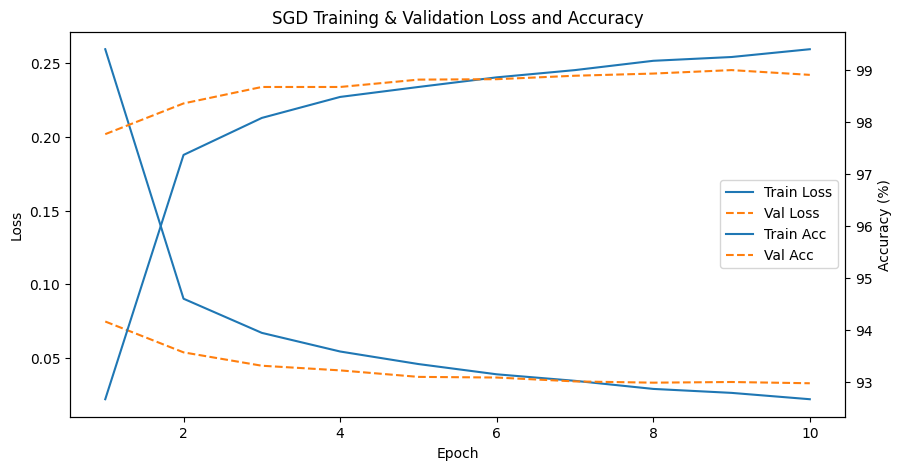

In [11]:
epochs_range = range(1, len(sgd_train_losses) + 1)

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.set_xlabel('Epoch')

ax1.set_ylabel('Loss')

ax1.plot(
    epochs_range,
    sgd_train_losses,
    label='Train Loss'
)

ax1.plot(
    epochs_range,
    sgd_val_losses,
    linestyle='dashed',
    label='Val Loss'
)

ax2 = ax1.twinx()

ax2.set_ylabel('Accuracy (%)')

ax2.plot(
    epochs_range,
    sgd_train_accuracies,
    label='Train Acc'
)

ax2.plot(
    epochs_range,
    sgd_val_accuracies,
    linestyle='dashed',
    label='Val Acc'
)

plt.title(
    "SGD Training & Validation Loss and Accuracy"
)

lines_1, labels_1 = ax1.get_legend_handles_labels()

lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='center right'
)

plt.show()


##Comparison Table

In [12]:
results = pd.DataFrame({

    "Model": ["Adam", "SGD"],

    "Accuracy": [
        f"{adam_test_accuracy:.2f}%",
        f"{sgd_test_accuracy:.2f}%"
    ],

    "Loss": [
        adam_test_loss,
        sgd_test_loss
    ]
})

print(results)

  Model Accuracy      Loss
0  Adam   99.12%  0.035997
1   SGD   99.13%  0.025365
